In [1]:
# === Direct ARCO → Zarr for: u850, v850, z500, tcwv, msl ===
import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import dask.bag as db

import gcsfs
fs = gcsfs.GCSFileSystem(token='anon')  # public access

import xesmf as xe
from dask.distributed import LocalCluster,Client


cluster = LocalCluster(n_workers=6, memory_limit='32GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 66,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44987,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41121,Total threads: 11
Dashboard: http://127.0.0.1:32973/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:35255,


In [2]:
import matplotlib.pyplot as plt

In [3]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"
ds = xr.open_zarr(zarr_out)

ds_variables = ds[['u850','v850','msl','z500','tcwv']]
ds_variables['tcwv'] = np.log(1+ds_variables['tcwv'])
ds_variables = ds_variables.to_array('var_name')

# dayofyearclim = ds_variables.rolling(time=30,center=True).mean().groupby('time.dayofyear').mean().rename('mean').load()
# dayofyearstd = ds_variables.rolling(time=30,center=True).construct('periods').groupby('time.dayofyear').std(['time','periods']).load()

# # dayofyearclim_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + dayofyearclim
# # dayofyearstd_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + dayofyearstd

# # ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd +1)

In [2]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"
ds = xr.open_zarr(zarr_out)

In [13]:
ds.data_normed.count('time').to_series().value_counts()

data_normed
31289    163800
Name: count, dtype: int64

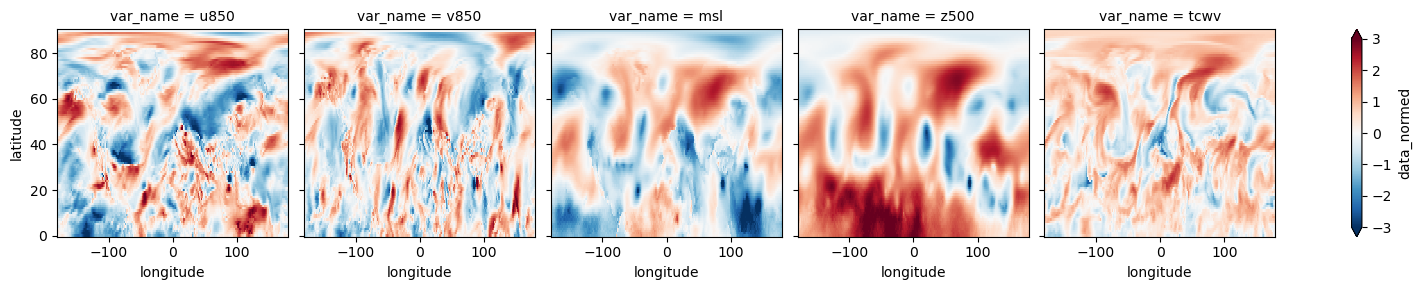

In [10]:
ds.data_normed.isel(time=-350).plot(col='var_name', vmax=3)

In [6]:
dayofyearclim_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + ds.dayofyear_mean
dayofyearstd_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + ds.dayofyear_std

In [8]:
ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd_timeseries +.1)

In [ ]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 21GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float32, chunksize=(1, 91, 23, 90), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

In [12]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.drop_vars('dayofyear').chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 22.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
# import zarr

# store = zarr.open(zarr_out, mode="a")
# # root = zarr.group(store=store)
# # print("Before deletion:", list(root.keys()))
# del store["mean_fields"]
# del store["std_fields"]
# del store["dayofyear"]
# del store["data_normed"]
# for k in store.keys():
#     print(k)

u850
latitude
time
longitude
z500
msl
tcwv
v850
var_name


In [25]:
ds = xr.open_zarr(zarr_out)
ds

<xarray.Dataset> Size: 21GB
Dimensions:    (time: 31289, latitude: 91, longitude: 360, var_name: 5)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
Data variables:
    u850       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    z500       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    tcwv       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    v850       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>

In [26]:
chunks = {'dayofyear': 366, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'dayofyear_mean': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
enc = {'dayofyear_std': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_out.astype(np.float32).to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [16]:
ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd_timeseries +0.1)

In [17]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 38.19 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-09 18:13:41,272 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f6f48b0f710>>, <Task finished name='Task-4' coro=<Worker.ha

KilledWorker: Attempted to run task ('array-5fcac772b4788877d6947c206126a4f4', 0, 0, 0, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:36243. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

2025-09-09 18:13:43,287 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,287 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,688 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,736 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,742 - distributed.nanny - ERROR - Worker process died unexpectedly


In [11]:
ds_normed = (ds_variables.groupby('dayofyear') - dayofyearclim)#.groupby('dayofyear')/dayofyearstd

ValueError: Please pass `labels` to UniqueGrouper when grouping by a chunked array.

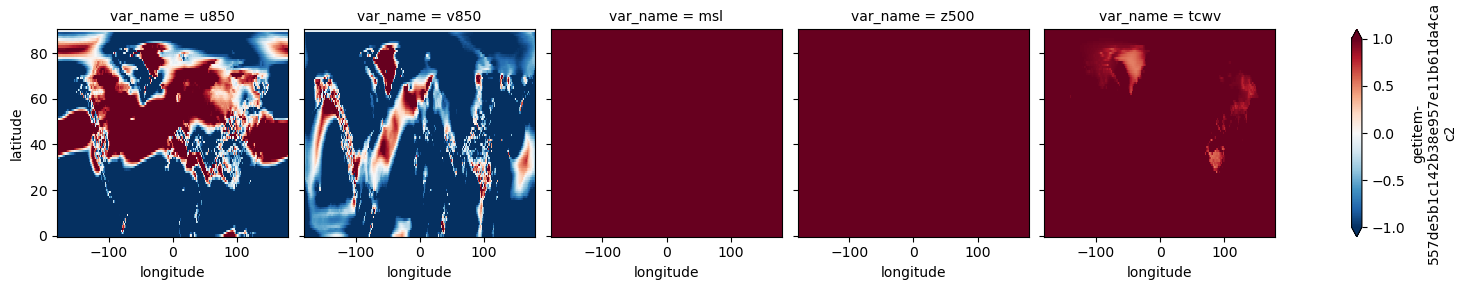

In [33]:
dayofyearclim.min('dayofyear').plot(col='var_name', vmax=1)

In [11]:
dayofyearstd_timeseries.count('time').min().values

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))


array(30522)

In [ ]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"


input_variables = ["u850","v850","msl","z500","tcwv"]

ds_atm = xr.open_zarr(zarr_out)
# ds_mean = ds_atm.mean_fields.sel(var_name = input_variables)
# ds_std = ds_atm.std_fields.sel(var_name = input_variables)
# ds_atm = ds_atm[input_variables].to_array('var_name')
# ds_atm = (ds_atm-ds_mean)/ds_std
ds_atm = ds_atm.data_normed.sel(var_name =input_variables )
ds_atm = ds_atm.transpose('time','var_name','latitude','longitude')

lon_min, lon_max, lat_min, lat_max = [-128, 53, 0, 88]
if ds_atm.latitude.diff('latitude')[0]<0:
    lat_min, lat_max = lat_max, lat_min
ds_atm = ds_atm.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))


In [13]:
ds_atm.isnull().max().values

array(False)

In [5]:
ds_test = ds.sel(longitude=20, latitude=20).load()

In [21]:
df = ds_test[['v850','u850','tcwv','z500','msl']].to_dataframe()

<Axes: ylabel='Frequency'>

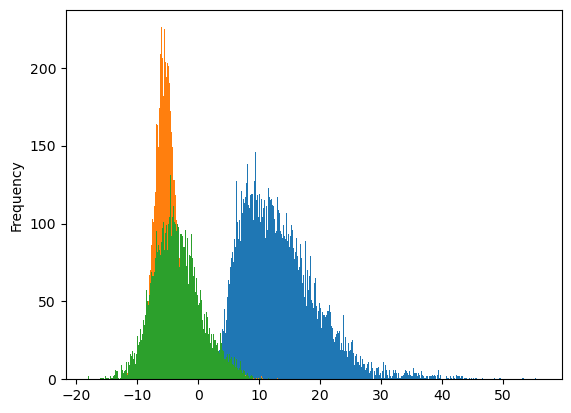

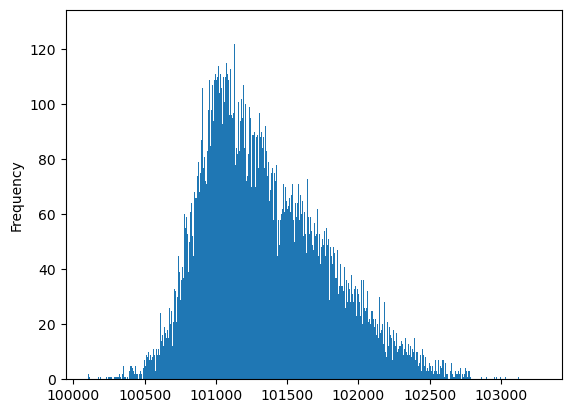

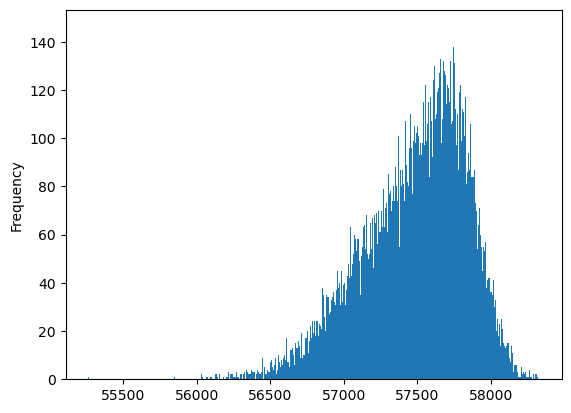

In [26]:
df.tcwv.plot.hist(bins=1000)
df.u850.plot.hist(bins=1000)
df.v850.plot.hist(bins=1000)
plt.figure()
df.msl.plot.hist(bins=1000)

plt.figure()
df.z500.plot.hist(bins=1000)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


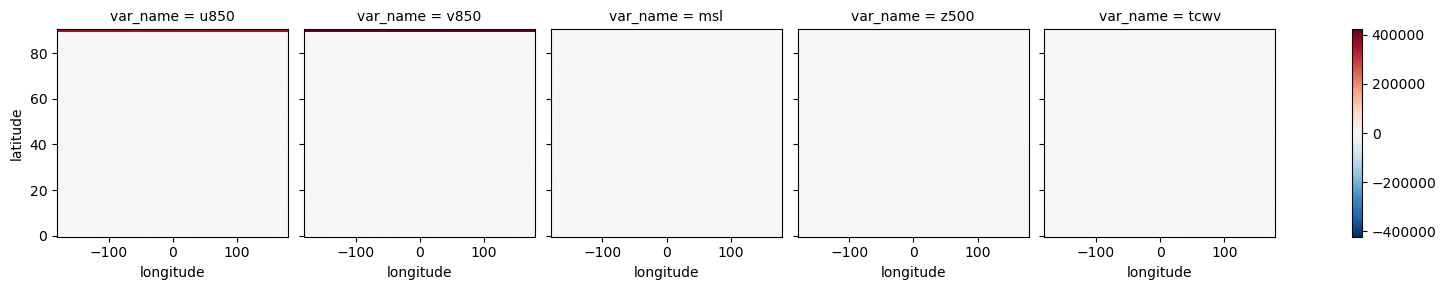

In [38]:
ds_normed.isel(time=-1).plot(col='var_name')

In [5]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 21GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float32, chunksize=(1, 256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

In [7]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 19.09 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-09 17:42:22,964 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back

OSError: [Errno 28] No space left on device

2025-09-09 17:43:30,455 - distributed.worker - ERROR - Exception during execution of task ('groupby_nanmean-simple-reduce-partial-d80ed9ff0bc3253a9aaade22c8ba3131', 3, 0, 0, 7)
Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/buffer.py", line 184, in __getitem__
    return self.fast[key]
           ~~~~~~~~~^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/lru.py", line 117, in __getitem__
    result = self.d[key]
             ~~~~~~^^^^^
KeyError: ('groupby_nanmean-chunk-0fa1d0a7229d282cfee019bf5fe78bbd', 3, 0, 0, 29)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib

In [30]:
dayofyearclim_timeseries

<xarray.DataArray (time: 31289, var_name: 5, latitude: 91, longitude: 360)> Size: 21GB
dask.array<add, shape=(31289, 5, 91, 360), dtype=float32, chunksize=(366, 1, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242

In [11]:
ds.v850

<xarray.DataArray 'v850' (time: 31289, latitude: 91, longitude: 360)> Size: 4GB
dask.array<open_dataset-v850, shape=(31289, 91, 360), dtype=float32, chunksize=(256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0

In [9]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 41GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float64, chunksize=(1, 256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242

(array([3.37022300e+06, 4.48650580e+07, 9.22162580e+07, 9.50291880e+07,
        1.18269304e+08, 1.58937144e+08, 1.60014994e+08, 1.44555199e+08,
        1.76030815e+08, 3.17394570e+07]),
 array([0.06474587, 0.50524163, 0.94573742, 1.38623333, 1.82672906,
        2.26722479, 2.70772076, 3.14821649, 3.58871222, 4.02920771,
        4.46970367]),
 <BarContainer object of 10 artists>)

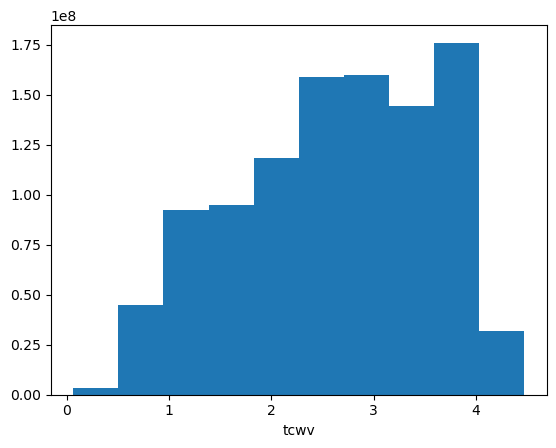

In [5]:
ds_variables.tcwv.plot.hist()

In [ ]:
dayofyearclim = u850_test.rolling(time=30,center=True).mean().groupby('time.dayofyear').mean()
dayofyearclim_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + dayofyearclim

dayofyearstd = u850_test.rolling(time=30,center=True).mean().groupby('time.dayofyear').std()
dayofyearstd_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + dayofyearstd


NameError: name 'u850_test' is not defined

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 6.000e+00, 6.000e+00,
        1.300e+01, 1.400e+01, 1.800e+01, 2.300e+01, 3.200e+01, 5.900e+01,
        8.000e+01, 1.110e+02, 1.590e+02, 2.120e+02, 2.830e+02, 4.140e+02,
        4.920e+02, 7.040e+02, 8.940e+02, 1.098e+03, 1.452e+03, 1.628e+03,
        1.851e+03, 2.032e+03, 2.077e+03, 2.020e+03, 2.049e+03, 1.859e+03,
        1.624e+03, 1.396e+03, 1.203e+03, 1.054e+03, 8.710e+02, 7.480e+02,
        6.070e+02, 5.390e+02, 4.160e+02, 3.880e+02, 3.600e+02, 2.640e+02,
        2.260e+02, 2.260e+02, 1.900e+02, 1.900e+02, 1.530e+02, 1.340e+02,
        1.160e+02, 1.360e+02, 9.900e+01, 9.400e+01, 7.600e+01, 6.700e+01,
        6.300e+01, 6.100e+01, 5.000e+01, 3.700e+01, 3.900e+01, 2.800e+01,
        2.500e+01, 3.100e+01, 2.000e+01, 2.400e+01, 1.900e+01, 1.700e+01,
        2.300e+01, 6.000e+00, 1.000e+01, 1.100e+01, 7.000e+00, 7.000e+00,
        7.000e+00, 3.000e+00, 7.000e+0

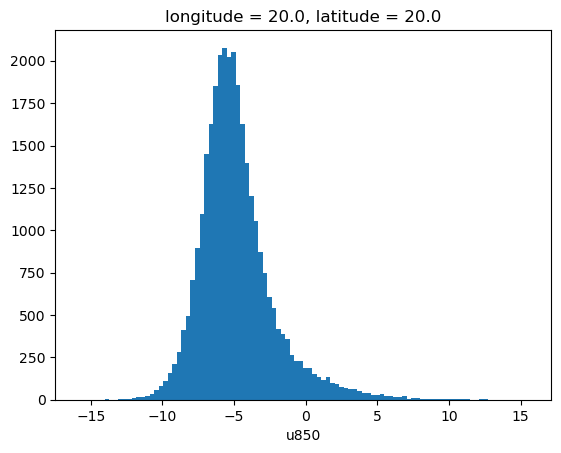

In [55]:
u850_test.plot.hist(bins=100)

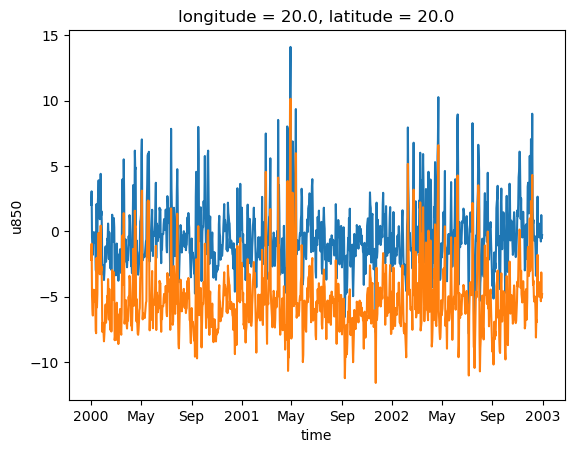

In [52]:
# ((u850_test-dayofyearclim_timeseries)/dayofyearstd_timeseries).sel(time=slice('2000','2001')).plot()
u_norm = ((u850_test-dayofyearclim_timeseries)/dayofyearstd_timeseries)

u_norm.sel(time=slice('2000','2002')).plot()
u850_test.sel(time=slice('2000','2002')).plot()

# dayofyearclim_timeseries.sel(time=slice('2000','2001')).plot(color='purple')
# dayofyearstd_timeseries.sel(time=slice('2000','2001')).plot(color='purple')


In [37]:
u850_clim = ds.u850.groupby(ds.time.dt.dayofyear).mean().compute()
u850_clim = (xr.concat([u850_clim.assign_coords(dayofyear=u850_clim.dayofyear-366),
           u850_clim,
           u850_clim.assign_coords(dayofyear=u850_clim.dayofyear+366),], dim='dayofyear').rolling(dayofyear=30, center=True).mean()
    .sel(dayofyear=np.arange(1,367))
)

u850_std = ds.u850.groupby(ds.time.dt.dayofyear).std().compute()
u850_std = (xr.concat([u850_std.assign_coords(dayofyear=u850_std.dayofyear-366),
           u850_std,
           u850_std.assign_coords(dayofyear=u850_std.dayofyear+366),], dim='dayofyear').rolling(dayofyear=30, center=True).mean()
    .sel(dayofyear=np.arange(1,367))
)

In [38]:
u850_clim_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + u850_clim

u850_std_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + u850_std

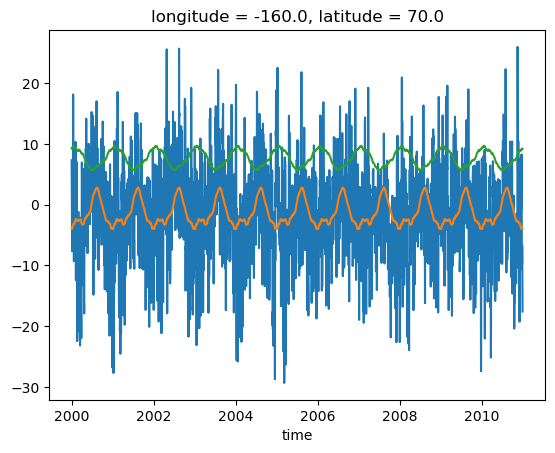

In [ ]:
ds.u850.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()
u850_clim_timeseries.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()
u850_clim_timeseries.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()




In [ ]:
u850_norm = (ds.u850.isel(longitude=20, latitude=20) - u850_clim_timeseries.isel(longitude=20, latitude=20) )/u850_std_timeseries.isel(longitude=20, latitude=20) 
u850_norm.plot()


In [32]:
u850_clim

<xarray.DataArray 'u850' (dayofyear: 366, latitude: 91, longitude: 360)> Size: 48MB
array([[[ 1.9384865e-06,  1.9384865e-06,  1.9384865e-06, ...,
          1.9384865e-06,  1.9384865e-06,  1.9384865e-06],
        [ 3.1554263e+00,  3.1595283e+00,  3.1609359e+00, ...,
          3.1291299e+00,  3.1399581e+00,  3.1488085e+00],
        [ 3.2171385e+00,  3.2162206e+00,  3.2135944e+00, ...,
          3.2108912e+00,  3.2143621e+00,  3.2164881e+00],
        ...,
        [-6.1354580e+00, -6.3186903e+00, -6.5102510e+00, ...,
         -5.5550876e+00, -5.7531958e+00, -5.9469919e+00],
        [-5.6765432e+00, -5.9046578e+00, -6.1334491e+00, ...,
         -4.9610529e+00, -5.1923432e+00, -5.4236126e+00],
        [-5.0670886e+00, -5.3377218e+00, -5.6029816e+00, ...,
         -4.2475753e+00, -4.5138669e+00, -4.7772317e+00]],

       [[ 1.0625253e-06,  1.0625253e-06,  1.0625253e-06, ...,
          1.0625253e-06,  1.0625253e-06,  1.0625253e-06],
        [ 3.1441345e+00,  3.1482852e+00,  3.1497688e+00, ...,
          3.1178455e+00,  3.1286466e+00,  3.1374924e+00],
        [ 3.1905761e+00,  3.1895094e+00,  3.1867826e+00, ...,
          3.1849504e+00,  3.1881950e+00,  3.1901104e+00],
...
         -5.5101838e+00, -5.7177510e+00, -5.9166169e+00],
        [-5.6584263e+00, -5.8899989e+00, -6.1178942e+00, ...,
         -4.9305296e+00, -5.1676731e+00, -5.4021745e+00],
        [-5.0625496e+00, -5.3359137e+00, -5.5975428e+00, ...,
         -4.2467370e+00, -4.5152087e+00, -4.7751098e+00]],

       [[ 1.9423298e-06,  1.9423298e-06,  1.9423298e-06, ...,
          1.9423298e-06,  1.9423298e-06,  1.9423298e-06],
        [ 3.1400230e+00,  3.1443622e+00,  3.1459980e+00, ...,
          3.1129401e+00,  3.1240442e+00,  3.1331580e+00],
        [ 3.2096651e+00,  3.2092605e+00,  3.2071292e+00, ...,
          3.2018485e+00,  3.2058377e+00,  3.2084918e+00],
        ...,
        [-6.1399951e+00, -6.3240867e+00, -6.5131173e+00, ...,
         -5.5477242e+00, -5.7492685e+00, -5.9464145e+00],
        [-5.6831670e+00, -5.9124961e+00, -6.1409340e+00, ...,
         -4.9654980e+00, -5.1977711e+00, -5.4278884e+00],
        [-5.0829706e+00, -5.3533745e+00, -5.6172366e+00, ...,
         -4.2631474e+00, -4.5305448e+00, -4.7934813e+00]]],
      shape=(366, 91, 360), dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Attributes:
    regrid_method:  bilinear

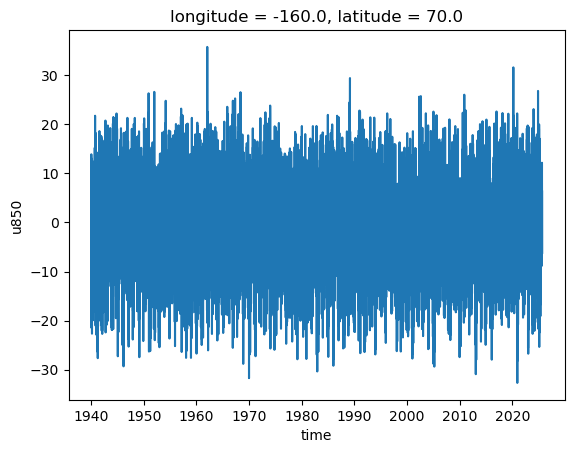

In [31]:
ds.u850.isel(latitude=20, longitude=20).plot()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 55.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


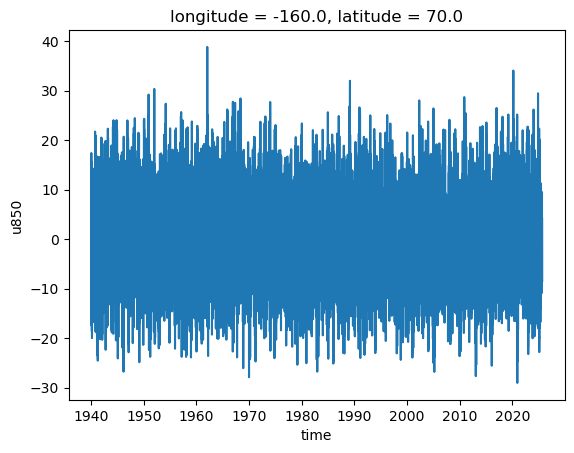

In [30]:
(ds.u850.groupby(ds.time.dt.dayofyear) - u850_clim ).isel(latitude=20, longitude=20).plot()

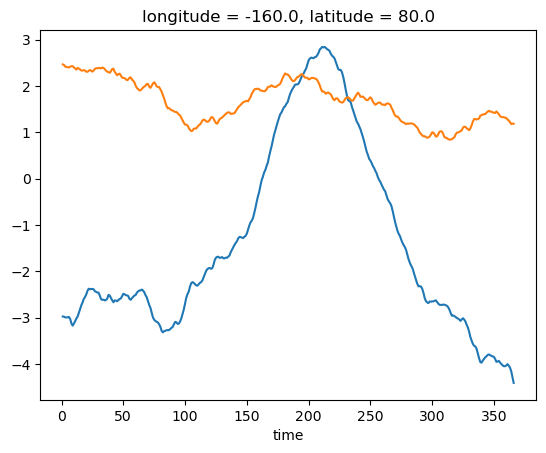

In [15]:
u850_clim.isel(latitude=20, longitude=20).rename(dayofyear='time').lntime.filter('moving_average', cutoff=30).plot()
u850_clim.isel(latitude=10, longitude=20).rename(dayofyear='time').lntime.filter('moving_average', cutoff=30).plot()